In [18]:
%matplotlib inline

import matplotlib.pyplot as plt

import cv2
import numpy as np

from tqdm import trange
import tqdm
import random

import scipy.io

from sklearn.cluster import MiniBatchKMeans
from sklearn.neighbors import NearestNeighbors

import math

SEED = 95667  
random.seed(SEED)
np.random.seed(SEED)

# Image Display

In [19]:
def show_image_and_keypoints( image , kps ) :
    cv2.drawKeypoints( image, kps, image, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS )

    plt.figure(figsize = (10,10))
    plt.imshow(image, aspect='auto')
    plt.axis('off')
    plt.title('Keypoints and descriptors.')
    plt.show()

In [20]:
def show_top_images_grid(dataset_path, indices, id_test, ids, labels, cols=4):
    """
    Fetches the query image and its top matches, displaying them in a grid.
    cols: Number of columns you want in the grid.
    """
    images_to_show = []
    titles = []
    
    # 1. Fetch the Query Image
    label = (ids[id_test] - 1) // 80
    name = f"{dataset_path}/jpg/{label}/image_{str(ids[id_test]).zfill(4)}.jpg"
    
    image = cv2.imread(name)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    images_to_show.append(image)
    titles.append(f"Query Label: {labels[id_test]}\n(ID: {ids[id_test]})")

    indice = 0
    # 2. Fetch the Match Images from indices
    for i in indices[0]:
        label_i = labels[i]
        name = f"{dataset_path}/jpg/{label_i}/image_{str(ids[i]).zfill(4)}.jpg"
        
        image = cv2.imread(name)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        images_to_show.append(image)
        titles.append(f"{indice}° Match: ID {ids[i]} \n Label: {label_i} - {'Correct' if label_i == labels[id_test] else 'Incorrect'}")
        indice += 1 
    
    # Create the Figure and Subplots Header
    # Adjust figsize based on your layout preference (width, height)
    fig_header, axes_header = plt.subplots(1, 2, figsize=(20, 4))

    axes_header[0].imshow(images_to_show[0])
    axes_header[0].set_title(f'Query. \n Label: {labels[id_test]}\n(ID: {ids[id_test]})')
    axes_header[0].axis('off') # Hide the axis ticks and borders

    axes_header[1].imshow(images_to_show[1])
    axes_header[1].set_title(f'Sanity Test. \n Label: {labels[indices[0][0]]}\n(ID: {ids[indices[0][0]]})')
    axes_header[1].axis('off') # Hide the axis ticks and borders
    
    
    # 3. Calculate Grid Dimensions
    n_images = len(images_to_show) - 2
    rows = math.ceil(n_images / cols)
    
    # 4. Create the Figure and Subplots
    # Adjust figsize based on your layout preference (width, height)
    fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
    
    # Flatten axes array to easily iterate over it, even if it's a 2D grid
    if n_images > 1:
        axes = axes.flatten()
    else:
        axes = [axes] # Handle edge case where there's only 1 image
        
    # 5. Populate the Grid
    for idx in range(len(axes)):
        if idx < n_images:
            axes[idx].imshow(images_to_show[idx+2])
            axes[idx].set_title(titles[idx+2])
            axes[idx].axis('off') # Hide the axis ticks and borders
        else:
            # Turn off empty subplots if the grid isn't perfectly filled
            axes[idx].axis('off') 
            
    plt.tight_layout()
    plt.show()

# Generate descriptors

In [21]:
# usa algum algoritmo para detectar e descrever keypoints
def detect_and_describe_keypoints ( image, algorithm='orb' ) :
    
    image_gray = cv2.cvtColor( image , cv2.COLOR_BGR2GRAY )
        
    if algorithm == 'sift' :
        keypoint = sift = cv2.SIFT_create()
    
    elif algorithm == 'orb' :
        keypoint = cv2.ORB_create()
   
    else :
        print('Error: algorithm not defined')
        return None
    
    kps = keypoint.detect( image_gray, None )    

    # Describing Keypoints
    kps, descs = keypoint.compute( image_gray, kps )
    
    return kps, descs

In [22]:
def create_bovw_descriptors (image, dictionary, algorithm='orb') :
    
    descs = detect_and_describe_keypoints( image, algorithm=algorithm )[1] # retorna os keypoints e seus descritores

    predicted = dictionary.predict(np.array(descs, dtype=np.double))
    
    desc_bovw = np.histogram(predicted, bins=range(0, dictionary.n_clusters+1))[0]
    
    return desc_bovw

In [23]:
def create_dictionary_kmeans ( vocabulary , num_cluster ) :
  
    print( ' -> [I] Dictionary Info:\n', 
        '\nTrain len: ', len(vocabulary),
        '\nDimension: ', len(vocabulary[0]),
        '\nClusters: ', num_cluster 
        )

    dictionary = MiniBatchKMeans( n_clusters=num_cluster, batch_size=1000, random_state=SEED )

    print ( 'Learning dictionary by Kmeans...')
    dictionary = dictionary.fit( vocabulary )
    print ( 'Done.')

    return dictionary

# Data

In [24]:
def create_vocabulary ( dataset_path , algorithm='orb', show_image=False , debug=False ) :

    mat = scipy.io.loadmat( dataset_path+'/datasplits.mat' )

    ids = mat['trn1'][0] #  'val1' or 'tst1' 
    
    if algorithm == 'orb' :
        train_descs = np.ndarray( shape=(0,32) , dtype=float )
    elif algorithm == 'sift' :
        train_descs = np.ndarray( shape=(0,128) , dtype=float )
    else :
        print('Error:Algorithm not defined.')
        return None

    for id in tqdm.tqdm(ids, desc='Processing train set') :
    
        label = (id - 1) // 80
        name = dataset_path + '/jpg/' + str(label) + '/image_' + str(id).zfill(4) + '.jpg'

        image = cv2.imread( name )
        
        if image is None:
            print(f'Reading image Error. Path: {name}')
            return None

        kps, descs = detect_and_describe_keypoints ( image, algorithm=algorithm )
            
        train_descs = np.concatenate((train_descs, descs), axis=0)
        
        if show_image :
            show_image_and_keypoints(image, kps)

        if debug :
            print( name )
            print( 'Number of keypoints: ', len(kps) )
            print( 'Number of images: ', len(ids) )
            print( 'Descriptor size: ', len(descs[0]) )
            print( type(descs[0]) )
      
    print( ' -> [I] Image Loader Info:\n', 
      '\nTrain len: ', len(train_descs),
      '\nNumber of images: ', len(ids),
      '\nDescriptor size: ', len(descs[0])      
      )
    
    return train_descs

# Dictionary

In [25]:
def represent_dataset( dataset_path, dictionary, test=False, algorithm='orb' ) :

    mat = scipy.io.loadmat( dataset_path+'/datasplits.mat' )

    if test :
        ids = mat['tst1'][0] #  'tst1' or 'trn1' or 'val1'
    else :
        ids = mat['val1'][0] #  'tst1' or 'trn1' or 'val1'
    
    space = []
    labels = []
    
    for id in tqdm.tqdm(ids, desc='Processing test set' if test else 'Processing val set') :

        label = (id - 1) // 80
        name = dataset_path + '/jpg/' + str(label) + '/image_' + str(id).zfill(4) + '.jpg'

        image = cv2.imread( name )
        
        if image is None:
            print(f'Reading image Error. Path: {name}')
            return None

        desc_bovw = create_bovw_descriptors(image, dictionary, algorithm=algorithm)

        space.append(desc_bovw)
        labels.append(label)
        
    print( ' -> [I] Space Describing Info:\n', 
        '\nNumber of images: ', len(space), 
        '\nNumber of labels: ', len(labels),
        '\nDimension: ', len(space[0])
        )

    return space , labels 

In [26]:
def run_experiment ( space , labels , dictionary , dataset_path, test=False, algorithm='orb', top=10 ) :
    knn = NearestNeighbors(n_neighbors=top+1).fit(space)
    
    mat = scipy.io.loadmat( dataset_path+'/datasplits.mat' )

    if test :
        ids = mat['tst1'][0] #  'tst1' or 'trn1' or 'val1'
    else :
        ids = mat['val1'][0] #  'tst1' or 'trn1' or 'val1'
    
    accuracy_t = 0
    
    for id_test in tqdm.tqdm(ids, desc= 'running the test phase' if test else 'running the val phase') :
        
        label = (id_test - 1) // 80
        name = dataset_path + '/jpg/' + str(label) + '/image_' + str(id_test).zfill(4) + '.jpg'

        image = cv2.imread( name )
        
        desc_bovw = create_bovw_descriptors(image, dictionary, algorithm=algorithm)

        indices = knn.kneighbors(desc_bovw.reshape(1, -1))[1]

        labels_top = [ labels[i] for i in indices[0] ]

        accuracy = sum( np.equal(labels_top, label) )
        accuracy =( (accuracy-1)/(top) ) * 100
        accuracy_t = accuracy_t + accuracy
        
    print('Average accuracy in the', 'test' if test else 'validation', f'set: {accuracy_t/len(ids):5.2f}%')
    

# Experimental evaluation

In [27]:
def retrieve_single_image ( space , labels , dictionary , dataset_path, algorithm='orb', top=10 ) :
    knn = NearestNeighbors(n_neighbors=top+1).fit(space)
    
    mat = scipy.io.loadmat( dataset_path+'/datasplits.mat' )

    ids = mat['tst1'][0] #  'trn1' or 'val1'
    
    id_test = random.randrange( len(ids) )
        
    label = (ids[id_test] - 1) // 80
    name = dataset_path + '/jpg/' + str(label) + '/image_' + str(ids[id_test]).zfill(4) + '.jpg'
    
    image = cv2.imread( name )
    
    if image is None:
        print(f'Reading image Error. Path: {name}')
        return None

    desc_bovw = create_bovw_descriptors(image, dictionary, algorithm=algorithm)
    
    distances, indices = knn.kneighbors(desc_bovw.reshape(1, -1))
    
    # show_top_images(dataset_path, indices, id_test, ids, labels)
    show_top_images_grid(dataset_path, indices, id_test, ids, labels)
    
    labels_top = [ int(labels[i]) for i in indices[0] ]
    
    accuracy = sum( np.equal( label , labels_top ) )
    accuracy =( (accuracy-1)/(top) ) * 100 
    
    print(f'Accuracy for image id {ids[id_test]}: {accuracy:5.2f}%')
    
    print(name)    
    print(f'Image: {ids[id_test]} with label {labels[id_test]}')    
    print(f'Closest image: {ids[indices[0][0]]} with distance {distances[0][0]} and label {labels[indices[0][0]]}')
    print('Distances: ',distances)
    print('Indices: ',indices[0])
    print('Labels: ',labels_top)

# Tune

In [30]:
dataset_path = '/Users/nicholasbarbosa/Mestrado/inf692/flowers_classes'# ************* INSERT HERE YOUR DATASET PATH ******************
algorithm = 'orb' # Chose the detector/descriptor: 'orb' or 'sift'

In [31]:
# Create the vocabulary of visual words by detecting and describing all keypoints 
# in all images in the training split of the dataset.
vocabulary = create_vocabulary( dataset_path, algorithm=algorithm ) 

Processing train set: 100%|██████████| 680/680 [00:13<00:00, 52.09it/s] 

 -> [I] Image Loader Info:
 
Train len:  333473 
Number of images:  680 
Descriptor size:  32


In [40]:
num_cluster = 200 # SET HERE THE BoVW DESCRIPTOR SIZE 

# Clusterize the vocabulary of visual words detected and described in the training 
# split of the dataset in $NUM_CLUSTER$ clusters.
dictionary = create_dictionary_kmeans( vocabulary , num_cluster=num_cluster )

# Using the centroids of the created clusters, represent all images in the validation split 
# of the dataset. 
space, labels = represent_dataset ( dataset_path , dictionary, algorithm=algorithm )

# For each image of the validation split of the dataset, use the image as the query
# for the image retrieval problem, i.e., describe the image using the BoVW, and search
# for the k closest descriptors of the images in the validation split dataset. After that,
# measure the accuracy of the image retrieval by counting how many of the k retrieved 
# images has the same label of the query image, and divide it by k. This result will 
# the accuracy of the image retrieval result for that specific image. 
# Repeat it for each image of the validation split of the dataset and compute the average of 
# all calculated accuracies.

run_experiment( space, labels, dictionary, dataset_path, algorithm=algorithm )

 -> [I] Dictionary Info:
 
Train len:  333473 
Dimension:  32 
Clusters:  200
Learning dictionary by Kmeans...
Done.


Processing val set: 100%|██████████| 340/340 [00:02<00:00, 134.04it/s]


 -> [I] Space Describing Info:
 
Number of images:  340 
Number of labels:  340 
Dimension:  200


running the val phase: 100%|██████████| 340/340 [00:02<00:00, 137.15it/s]

Average accuracy in the validation set: 15.56%


| Dic. Size  | SIFT | ORB-Euclidean | ORB-Hamming | etc. |
|---|---|---|---|---|
| 100  |  |  |   |   |
| 200  |  |  |   |   |
| 400  |  |  |   |   |
| 800  |  |  |   |   |

## Test

In [37]:
algorithm = 'orb' # Chose the detector/descriptor: 'orb' or 'sift'
num_cluster =  200 # SET HERE THE BoVW DESCRIPTOR SIZE 

vocabulary = create_vocabulary( dataset_path, algorithm=algorithm ) 
dictionary = create_dictionary_kmeans( vocabulary , num_cluster=num_cluster )

# Using the centroids of the created clusters, represent all images in the testing split 
# of the dataset. 
space, labels = represent_dataset ( dataset_path , dictionary, test=True, algorithm=algorithm )

# For each image of the testing split of the dataset, use the image as the query
# for the image retrieval problem, i.e., describe the image using the BoVW, and search
# for the k closest descriptors of the images in the testing split dataset. After that,
# measure the accuracy of the image retrieval by counting how many of the k retrieved 
# images has the same label of the query image, and divide it by k. This result will 
# the accuracy of the image retrieval result for that specific image. 
# Repeat it for each image of the testing split of the dataset and compute the average of 
# all calculated accuracies.

run_experiment( space, labels, dictionary, dataset_path, test=True, algorithm=algorithm )

Processing train set: 100%|██████████| 680/680 [00:12<00:00, 56.38it/s] 


 -> [I] Image Loader Info:
 
Train len:  333473 
Number of images:  680 
Descriptor size:  32
 -> [I] Dictionary Info:
 
Train len:  333473 
Dimension:  32 
Clusters:  200
Learning dictionary by Kmeans...
Done.


Processing test set: 100%|██████████| 340/340 [00:02<00:00, 126.07it/s]


 -> [I] Space Describing Info:
 
Number of images:  340 
Number of labels:  340 
Dimension:  200


running the test phase: 100%|██████████| 340/340 [00:02<00:00, 142.00it/s]

Average accuracy in the test set: 18.68%


| Dataset  | Accuracy | Implementation Details |
|---|---|---|
| Flowers-17  |   | algo: - dic. size:  |
|   |   |   |


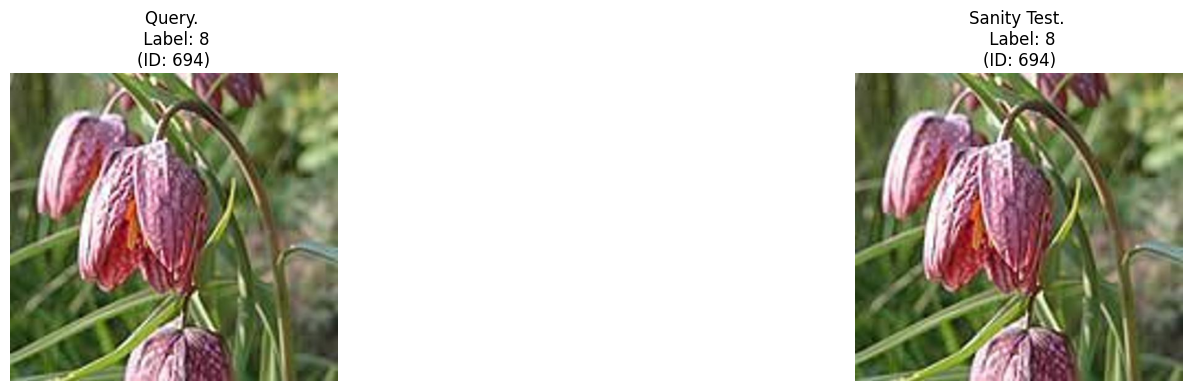

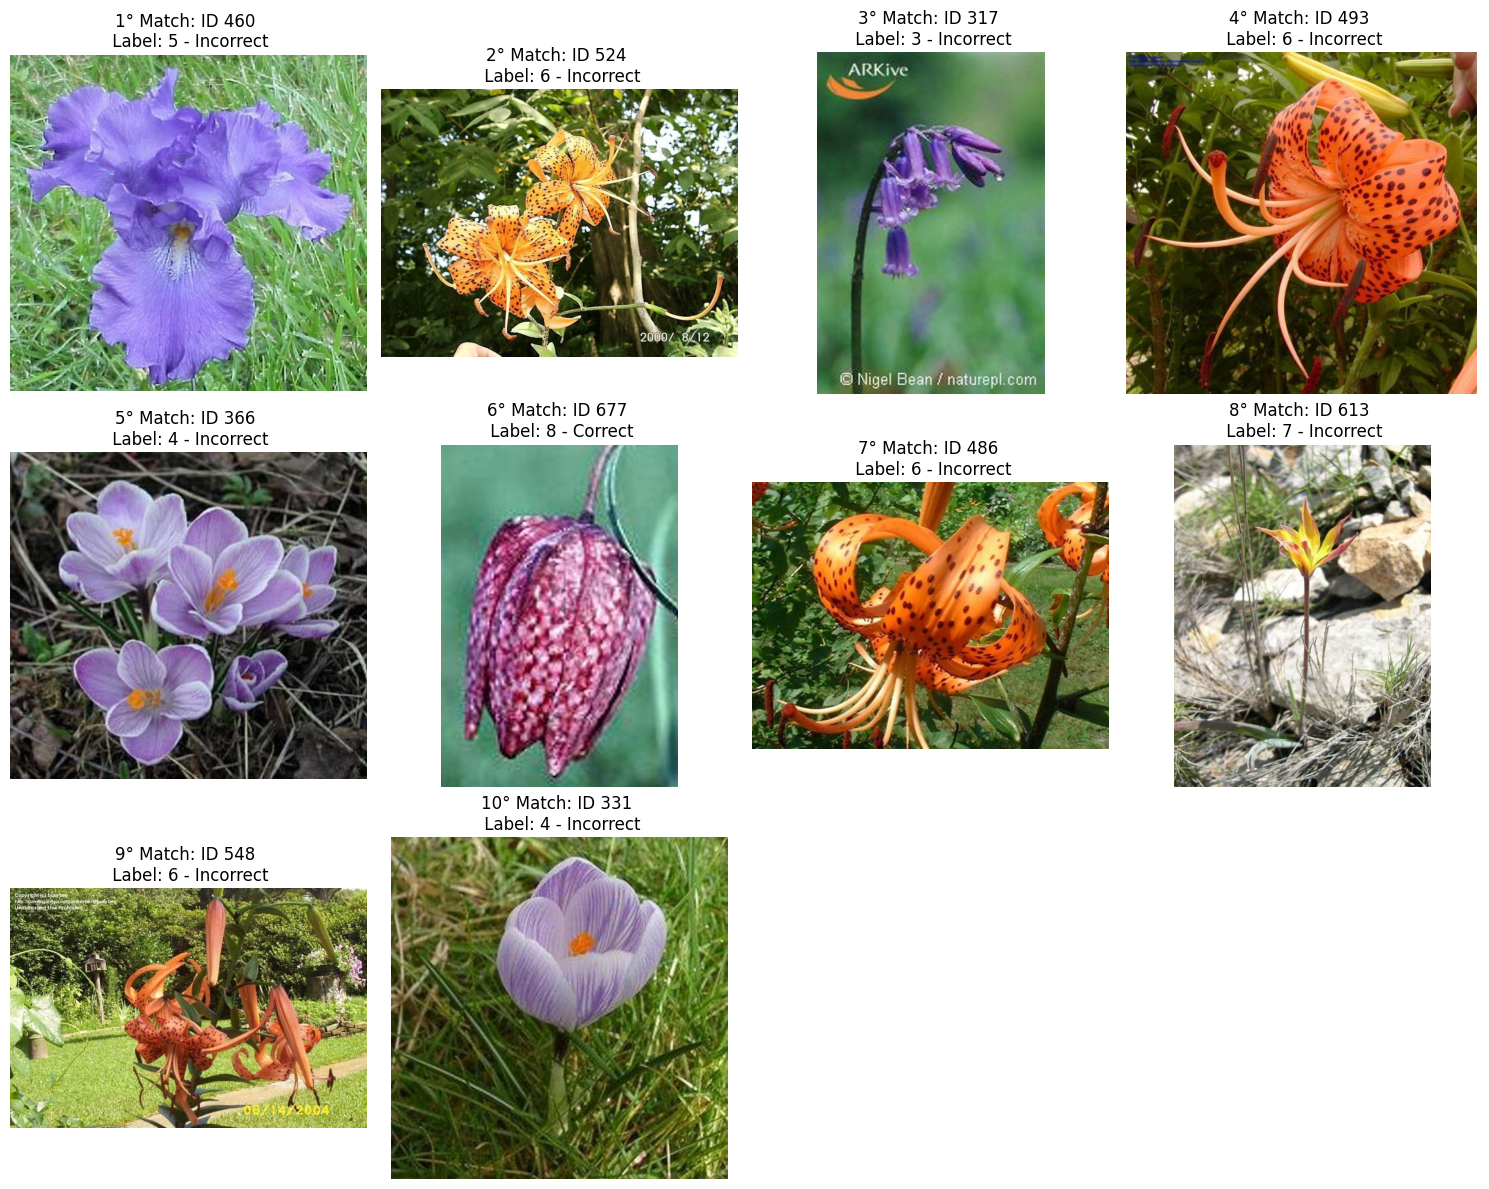

Accuracy for image id 694: 10.00%
/Users/nicholasbarbosa/Mestrado/inf692/flowers_classes/jpg/8/image_0694.jpg
Image: 694 with label 8
Closest image: 694 with distance 0.0 and label 8
Distances:  [[ 0.         35.35533906 35.38361203 35.63705936 35.83294573 35.91656999
  35.91656999 35.94440151 36.08323711 36.19392214 36.24913792]]
Indices:  [173 117 130  76 128  94 166 124 158 131  82]
Labels:  [8, 5, 6, 3, 6, 4, 8, 6, 7, 6, 4]


In [38]:
# For a random image of the testing split of the dataset, use the image as the query
# for the image retrieval problem, i.e., describe the image using the BoVW, and search
# for the k closest descriptors of the images in the testing split dataset. After that,
# measure the accuracy of the image retrieval by counting how many of the k retrieved 
# images has the same label of the query image, and divide it by k. This result will 
# the accuracy of the image retrieval result for that specific image.
# Also display the query image, and all k images returned by the image retrieval problem.
# For each returned image, also display its class, and the Euclidean distance between its
# descriptor and the descriptor of the query image.
# Since the query image also is in the testing split of the dataset, it is expected that the
# first returned image is the query image itself, and the distance between the descriptor to 
# be zero.

retrieve_single_image( space, labels, dictionary, dataset_path , algorithm=algorithm)